# Assignment 1, Task 3

In [13]:
using JuMP
using Gurobi
# Set reusable Gurobi environment
const GRB_ENV = Gurobi.Env()
Gurobi_constructor = ()->Gurobi.Optimizer(GRB_ENV)
using Plots
using Printf

Set parameter Username
Set parameter LicenseID to value 2773792
Academic license - for non-commercial use only - expires 2027-02-02


## Data


In [14]:
include("assignment_1_data.jl")

# Sets
I = 1:nS
J = 1:nC
S = 1:nSc

1:20

# Deterministic solution:

In [31]:
m1 = Model(Gurobi_constructor)
set_silent(m1)

@variable(m1, x[I,J,S] >= 0)
@variable(m1, r[I] >= 0)
@variable(m1, z[J,S] >= 0)
@variable(m1, y[I], Bin)

@objective(m1, Min, sum(r[i]*C[i] for i in I) + sum(P*(sum(x[i,j,s]*T[i,j] for i in I) + z[j,s]*u) for j in J, s in S))

@constraint(m1, [s=S,j=J], sum(x[i,j,s] for i in I) + z[j,s] >= D[j,s])
# @constraint(m1, sum(y[i] for i in I) <= n)
@constraint(m1, [i=I], r[i] <= B[i])
@constraint(m1, [i=I, s=S], sum(x[i,j,s] for j in J) <= r[i])

optimize!(m1)
println("Termination status: $(termination_status(m1))")

if termination_status(m1) == OPTIMAL
    println("\nOptimal objective value: $(objective_value(m1))\n")
    r_opt = value.(r)
    obj_opt = objective_value(m1)
    # print("Suppliers selected:")
    for i in I
        # if value(y[i]) == 1
        #     print(" $i")
        # end
        println("r[$i]: $(value(r[i]))")
    end
    # println("\nCapacity reserved from each supplier:")
    # for i in I 
    #     println("Supplier $i: $(value(r[i]))")
    # end
else
    println("No optimal solution found")
end

Termination status: OPTIMAL

Optimal objective value: 11423.7

r[1]: 51.0
r[2]: 0.0
r[3]: 0.0
r[4]: 80.0
r[5]: 285.0
r[6]: 58.0
r[7]: 0.0
r[8]: 70.0
r[9]: 185.0
r[10]: 0.0
r[11]: 430.0
r[12]: 363.0
r[13]: 433.0


## Question 2 — NAC formulation and augmented Lagrangian subproblem

Introduce a scenario copy $x_s$ of the capacity variable for each $s \in S$ and enforce nonanticipativity via the agreement variable $z$ and constraints $x_s = z$.

Write the augmented Lagrangian subproblem for scenario $s$ and implement it as a function.

Recall that the augmented Lagrangian adds a dual term $\lambda_s(x_s - z)$ and a quadratic penalty $\frac{\rho}{2}(x_s - z)^2$ to the original objective for scenario $s$. With $x_s$ as a free variable this becomes a QP, which Gurobi handles directly.

**Tip:** Write the augmented Lagrangian objective by hand before translating it to code.

In [29]:
function solve_subproblem(s, lam1s, z1, rho)
    m = Model(Gurobi_constructor)
    set_silent(m)

    # First-stage variable
    @variable(m, r[I] >= 0)

    # Variables for scenario s
    @variable(m, x[I,J] >= 0)
    @variable(m, z[J] >= 0)

    @objective(m, Min, sum(lam1s*r[i] for i in I) + (rho/2)*(sum(r[i]-z1[i] for i in I))^2 
                        + sum(r[i]*C[i] for i in I) + sum((sum(x[i,j]*T[i,j] for i in I) + z[j]*u) for j in J)
    )

    @constraint(m, [j=J], sum(x[i,j] for i in I) + z[j] >= D[j,s])
    @constraint(m, [i=I], r[i] <= B[i])
    @constraint(m, [i=I], sum(x[i,j] for j in J) <= r[i])

    optimize!(m)
    return value.(r)
end

solve_subproblem (generic function with 1 method)

## Question 3 — Two-stage progressive hedging

Implement progressive hedging with $\rho = 8$. Initialise $\lambda_s^0 = 0$ and $z^0 = 0$ for all $s$.

At each iteration $k$:
1. **x-update**: solve each per-scenario subproblem to get $x_s^{k+1}$;
2. **z-update**: $z^{k+1} = \sum_s P_s\, x_s^{k+1}$;
3. **$\lambda$-update**: $\lambda_s^{k+1} = \lambda_s^k + \rho(x_s^{k+1} - z^{k+1})$.

Run for 25 iterations, reporting $z^k$ and the primal/dual squared residuals at each step.
Verify that the final $z$ matches $x^*$ from Question 1.

In [48]:
function run_PH_2stage(rho_val; n_iter=100, verbose=true)

    # TODO: initialise multipliers lam (vector of zeros, one per scenario)
    lam = zeros(length(S))
    # TODO: initialise agreement variable z = 0.0
    z = zeros(length(I))
    # TODO: initialise scenario solution vector xs (zeros)
    r = zeros(length(I), length(S))
    # TODO: initialise empty vectors r_prim and r_dual to store residuals
    r_prim = []
    r_dual = []

    if verbose
        println("ρ = $rho_val")
        println("Iter |    z     |  r_prim    r_dual  | x per scenario")
        println("-----+----------+--------------------+----------------")
    end

    for k in 1:n_iter
        # TODO: save z_prev (needed for dual residual)
        z_prev = copy(z)
        # Step 1 — x-update: solve per-scenario subproblem for each s
        # TODO
        for s in S
            rs = solve_subproblem(s, lam[s], z, rho_val)
            for i in I
                r[i,s] = rs[i]
            end
        end
        # Step 2 — z-update: probability-weighted average of xs
        # TODO
        for i in I
            z[i] = sum(P*r[i,s] for s in S)
        end
        # TODO: compute primal residual:  rp = sum_s P[s] * (xs[s] - z)^2
        rp = sum(P*(sum(r[i,s]-z[i] for i in I))^2 for s in S)
        # TODO: compute dual residual:    rd = sum_s P[s] * (z - z_prev)^2
        rd = sum(P*sum(z[i]-z_prev[i] for i in I)^2 for s in S)
        # TODO: append rp and rd to their respective vectors
        push!(r_prim, rp)
        push!(r_dual, rd)
        # Step 3 — lambda-update
        for s in S
            lam[s] = lam[s] + rho_val*(sum(r[i,s]- z[i] for i in I) )
        end
        # TODO

        if verbose
            # TODO: print k, z, rp, rd, and xs using @printf
            # @printf("%4d | %8.2f | %10.4e %10.4e | ", k,z,rp,rd)
            for s in S
                # @printf("%8.2f", xs[s])
            end
            # println()
        end
    end

    return r, z, lam, r_prim, r_dual
end

r, z2, lam2, rp2, rd2 = run_PH_2stage(12.5)

for i in I
    println("z[$i]: $(z2[i]), \t r[$i]: $(r_opt[i])")
end
println("Sum of z: $(sum(z2)), sum of r_opt: $(sum(r_opt))")

ρ = 12.5
Iter |    z     |  r_prim    r_dual  | x per scenario
-----+----------+--------------------+----------------
z[1]: 64.93858653136355, 	 r[1]: 51.0
z[2]: 2.524654508241984e-6, 	 r[2]: 0.0
z[3]: 2.7635487212894946e-6, 	 r[3]: 0.0
z[4]: 96.84048647288624, 	 r[4]: 80.0
z[5]: 283.16754924009007, 	 r[5]: 285.0
z[6]: 85.91559056590368, 	 r[6]: 58.0
z[7]: 2.569720537631853e-6, 	 r[7]: 0.0
z[8]: 73.8138056821433, 	 r[8]: 70.0
z[9]: 134.85495313309661, 	 r[9]: 185.0
z[10]: 2.5379486486652687e-6, 	 r[10]: 0.0
z[11]: 429.9999980539636, 	 r[11]: 430.0
z[12]: 351.5501328003469, 	 r[12]: 363.0
z[13]: 432.9999998484566, 	 r[13]: 433.0
Sum of z: 1954.081112724123, sum of r_opt: 1955.0


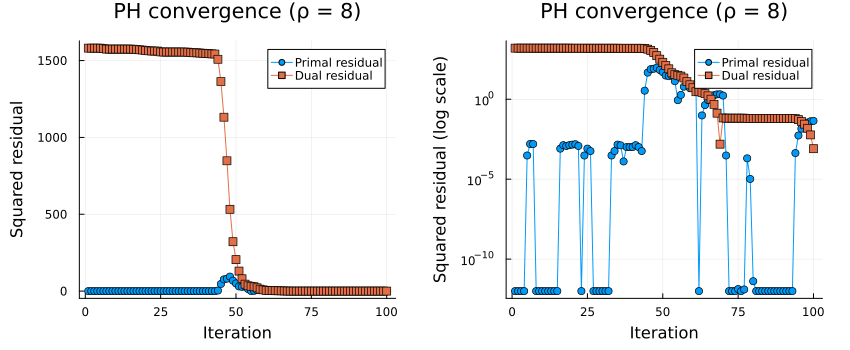

In [49]:
# Plotting code for Question 3
# Assumes: rp2, rd2  (primal/dual residual vectors from run_PH_2stage)

ε = 1e-12
iters = 1:length(rp2)

p_lin = plot(iters, rp2, label="Primal residual", marker=:circle,
    xlabel="Iteration", ylabel="Squared residual",
    title="PH convergence (ρ = 8)", legend=:topright)
plot!(p_lin, iters, rd2, label="Dual residual", marker=:square)

p_log = plot(iters, max.(rp2, ε), label="Primal residual", marker=:circle,
    yscale=:log10, xlabel="Iteration", ylabel="Squared residual (log scale)",
    title="PH convergence (ρ = 8)", legend=:topright)
plot!(p_log, iters, max.(rd2, ε), label="Dual residual", marker=:square)

plot(p_lin, p_log, layout=(1,2), size=(850,350), margin=5Plots.mm)